# 🔬 Customized YOLO with Attention for VIM Polyp Segmental Localization
### VIM Polyp Dataset · Polyp Detection & Localization

**Goal:** Detect and localize polyps in colonoscopy videos using a YOLO backbone augmented with attention modules. The VIM Polyp dataset includes video data, enabling temporal analysis for segmental localization.

**Dataset:** VIM Polyp: A Multimodal Dataset of Colonoscopy Videos, Histopathology Images, and Protein Expression Levels from Colorectal Polyps (Zenodo) — A multimodal dataset focusing on colonoscopy videos with polyp annotations.

> **Reference:** VIM Polyp Dataset: [https://zenodo.org/records/15388073](https://zenodo.org/records/15388073)

**Pipeline Overview:**
1. Environment Setup & Library Imports
2. Dataset Download & Structure (VIM Polyp Videos & Annotations)
3. Data Exploration & Segment Distribution (adapted for video frames)
4. Dataset Preparation for YOLO (video frame extraction, annotation conversion)
5. Custom YOLO Model with CBAM / Coordinate Attention
6. Training with Callbacks & Live Logging
7. Evaluation: mAP, Precision, Recall, Confusion Matrix
8. Attention Map Visualization (Grad-CAM)
9. Results Dashboard

---

## 1. Environment Setup

In [ ]:
%pip install torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/2.7 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 GB 2.4 MB/s eta 0:19:00
   ---------------------------------------- 0.0/2.7 GB 2.4 MB/s eta 0:19:00
   ---------------------------------------- 0.0/2.7 GB 2.4 MB/s eta 0:18:58
   ---------------------------------------- 0.0/2.7 GB 2.5 MB/s eta 0:17:54
   ---------------------------------------- 0.0/2.7 GB 3.0 MB/s eta 0:14:59
   ---------------------------------------- 0.0/2.7 GB 3.0 MB/s eta 0:15:08
   ---------------------------------------- 0.0/2.7 GB 3.2 MB/s eta 0:14:05
   ---------------------------------------- 0.0/2.7 GB 3.6 MB/s eta 0:12:40
   ---------------------------------------- 0.0/2.7 GB 3.3 MB/s 

In [ ]:
# Install the remaining computer vision & ML dependencies
%pip install -q "ultralytics>=8.3.0" albumentations scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Verify core packages and GPU
import torch
import ultralytics
import albumentations

print(f"✅ PyTorch {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
print(f"✅ torch.version.cuda: {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("❌ GPU NOT detected - this usually means the kernel is still using a CPU-only build or the notebook needs a restart after installation")
    print("   If you just installed PyTorch, restart the kernel and rerun this cell.")

print(f"✅ Ultralytics {ultralytics.__version__}")
print(f"✅ Albumentations {albumentations.__version__}")
print("✅ All packages ready.")

✅ PyTorch 2.6.0+cu118
✅ CUDA available: True
✅ torch.version.cuda: 11.8
✅ GPU: NVIDIA GeForce GTX 1660 Ti
✅ GPU Memory: 6.44 GB
✅ Ultralytics 8.4.90
✅ Albumentations 2.0.8
✅ All packages ready.


In [ ]:
import os, sys, shutil, random, json, yaml, math, time, warnings, re
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from ultralytics import YOLO

try:
    import torch
    import ultralytics.nn.tasks as _ultra_tasks
    torch.serialization.add_safe_globals([_ultra_tasks.ClassificationModel])
except Exception:
    # If this fails, loading may still work depending on torch/ultralytics versions.
    pass
import albumentations as A
from albumentations.pytorch import ToTensorV2

try:
    from pytorch_grad_cam import EigenCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    EigenCAM = None
    show_cam_on_image = None
    print("⚠️  pytorch-grad-cam not installed. Run: %pip install pytorch-grad-cam")

warnings.filterwarnings('ignore')

# =========================================================
# GOOGLE / COLAB
# =========================================================
# from google.colab import userdata, auth, drive
# from google import genai

# =========================================================
# HUGGING FACE
# =========================================================
# from huggingface_hub import login
# from datasets import Dataset, load_dataset

# hf_token = userdata.get('HF_TOKEN')
# login(token=hf_token)
# HF_TOKEN = hf_token

# Initialize the official Google GenAI SDK client
# GEMINI_API_KEY = userdata.get('gemini_api_key')
# gemini_client = genai.Client(api_key=GEMINI_API_KEY)

# from google.colab import auth
# auth.authenticate_user()
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Project paths
ROOT        = Path('vim_polyp_yolo') # Changed from 'hyperkvasir_yolo'
DATA_DIR    = ROOT / 'data'
RAW_DIR     = DATA_DIR / 'raw'          # raw VIM Polyp videos & annotations
YOLO_DIR    = DATA_DIR / 'yolo'         # YOLO-formatted dataset
RESULTS     = ROOT / 'results'
MODELS_DIR  = ROOT / 'models'

for d in [RAW_DIR, YOLO_DIR/'images'/'train', YOLO_DIR/'images'/'val',
          YOLO_DIR/'images'/'test', YOLO_DIR/'labels'/'train',
          YOLO_DIR/'labels'/'val', YOLO_DIR/'labels'/'test',
          RESULTS, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Project structure created.")

c:\Users\Mohamed.Motear\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🖥️  Device: cuda
   GPU: Quadro M2200
   VRAM: 4.3 GB
✅ Project structure created.


## 2. Dataset Download — VIM Polyp


In [ ]:
# ─── 3. Segment Extraction & Clean Dataset Prep for Classification ───────────
import os
import shutil
from pathlib import Path
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import GroupShuffleSplit

# Ensure default constants exist
SEED = 42
if 'ROOT' not in locals():
    ROOT = Path('vim_polyp_yolo')

# 1. Configuration & Class Filters
LOCAL_DATA_DIR = r"D:\Marina\colonVideosWithLabels"
CLASSES_TO_DROP = {'anastomosis', 'rectosigmoid', 'colon'}

all_video_files = []
unique_segments = set()

# Scan directory using os.scandir for path safety and performance
if os.path.exists(LOCAL_DATA_DIR):
    for entry in os.scandir(LOCAL_DATA_DIR):
        if entry.is_file():
            filename = entry.name

            # Skip hidden files and macOS metadata leftovers (._ files)
            if filename.startswith(".") or filename.startswith("._"):
                continue

            # Filter specifically for video formats
            if not filename.lower().endswith(('.avi', '.mp4', '.mkv')):
                continue

            stem = os.path.splitext(filename)[0]
            parts = stem.split('-')

            # Extract anatomical segment string from index 5
            if len(parts) > 5:
                segment = parts[5].lower().strip()

                if segment in CLASSES_TO_DROP:
                    continue

                unique_segments.add(segment)
                all_video_files.append((Path(entry.path), segment))

    print(f"✅ Found {len(all_video_files)} valid anatomical localization videos.")
else:
    print(f"❌ Local data directory not found at: {LOCAL_DATA_DIR}")

# 2. Dynamic Class Mapping
CLASS_NAMES = sorted(list(unique_segments))
NUM_CLASSES  = len(CLASS_NAMES)
CLASS_TO_ID  = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f"\nClasses ({NUM_CLASSES}):")
for i, c in enumerate(CLASS_NAMES):
    print(f"   [{i}] {c}")

PALETTE = plt.colormaps['tab10']
CLASS_COLORS = {cls: PALETTE(i % 10)[:3] for i, cls in enumerate(CLASS_NAMES)}

# 3. Artifact Filtering Function
def is_unwanted_frame(frame, brightness_thresh=15, variance_thresh=5):
    """
    Returns True if the frame is pitch black, a solid blue screen,
    or a blank color artifact lacking diagnostic information.
    """
    means, stddevs = cv2.meanStdDev(frame)

    # 1. Pitch-black frames
    if max(means) < brightness_thresh:
        return True

    # 2. Solid/blank screens
    if max(stddevs) < variance_thresh:
        return True

    # 3. Explicit check for digital blue screen artifacts (High Blue, low Green/Red)
    blue_mean = means[0][0]
    green_mean = means[1][0]
    red_mean = means[2][0]
    if blue_mean > 150 and green_mean < 40 and red_mean < 40:
        return True

    return False

# 4. Setup temporary folder for frame extraction before splitting
TEMP_FRAMES_DIR = ROOT / 'data' / 'temp_frames'
TEMP_FRAMES_DIR.mkdir(parents=True, exist_ok=True)

# 5. Extract Valid Frames from Videos
all_pairs = []
skipped_artifacts = 0

if all_video_files:
    for video_path, segment in tqdm(all_video_files, desc="Extracting clean frames for localization"):
        video_id = video_path.stem

        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            continue

        fps = cap.get(cv2.CAP_PROP_FPS) or 30
        frame_interval = max(1, int(fps / 1))  # Extract 1 frame per second of video
        frame_count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_count % frame_interval == 0:
                # Filter out unwanted black/blue artifact screens
                if is_unwanted_frame(frame):
                    skipped_artifacts += 1
                    frame_count += 1
                    continue

                frame_name = f"{video_id}_frame_{frame_count:05d}.jpg"
                frame_path = TEMP_FRAMES_DIR / frame_name

                # Save valid frame image
                cv2.imwrite(str(frame_path), frame)
                all_pairs.append((frame_name, segment))

            frame_count += 1
        cap.release()

    print(f"\n✅ Total valid extracted frames: {len(all_pairs)}")
    print(f"🗑️ Skipped {skipped_artifacts} unwanted artifact/blank frames.")
else:
    print("⚠️ No video files to process.")

# 6. Group-Aware Video-Level Split (Prevents Data Leakage)
# ──────────────────────────────────────────────────────────────────────────
splits = {'train': [], 'val': [], 'test': []}

if all_pairs:
    frame_names = [p[0] for p in all_pairs]
    frame_labels = [p[1] for p in all_pairs]
    video_ids = [name.rsplit('_frame_', 1)[0] for name in frame_names]

    df_pairs = pd.DataFrame({
        'frame_name': frame_names,
        'label': frame_labels,
        'video_id': video_ids
    })

    # First Split: Train vs Temp (Val + Test) based on Video ID
    gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
    train_idx, temp_idx = next(gss_outer.split(df_pairs, groups=df_pairs['video_id']))

    train_df = df_pairs.iloc[train_idx].reset_index(drop=True)
    temp_df = df_pairs.iloc[temp_idx].reset_index(drop=True)

    # Second Split: Val vs Test based on Video ID
    gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
    val_idx, test_idx = next(gss_inner.split(temp_df, groups=temp_df['video_id']))

    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)

    # Construct split mapping for organizing files
    splits = {
        'train': list(zip(train_df['frame_name'], train_df['label'])),
        'val':   list(zip(val_df['frame_name'], val_df['label'])),
        'test':  list(zip(test_df['frame_name'], test_df['label'])),
    }

    print(f"\n📊 Group-Based Split Summary (by Video ID):")
    print(f"   Train videos: {train_df['video_id'].nunique():<3} | Frames: {len(train_df)}")
    print(f"   Val videos:   {val_df['video_id'].nunique():<3} | Frames: {len(val_df)}")
    print(f"   Test videos:  {test_df['video_id'].nunique():<3} | Frames: {len(test_df)}")

# 7. Organize into YOLO Classification Folder Structure
YOLO_CLASSIFY_DIR = ROOT / 'yolo_classification_data'

if all_pairs:
    for split_name, split_data in splits.items():
        for frame_name, segment_label in tqdm(split_data, desc=f"Organizing {split_name} split"):
            dest_dir = YOLO_CLASSIFY_DIR / split_name / segment_label
            dest_dir.mkdir(parents=True, exist_ok=True)

            src_path = TEMP_FRAMES_DIR / frame_name
            dest_path = dest_dir / frame_name

            if src_path.exists():
                shutil.copy2(str(src_path), str(dest_path))

    # Clean up temp folder now that everything's been copied out
    if TEMP_FRAMES_DIR.exists():
        shutil.rmtree(TEMP_FRAMES_DIR)
    print(f"\n✅ Balanced YOLO classification structure successfully built at: {YOLO_CLASSIFY_DIR.absolute()}")

✅ Found 121 valid anatomical localization videos.

Classes (8):
  [0] ascending
  [1] cecum
  [2] descending
  [3] hepaticflexure
  [4] rectum
  [5] sigmoid
  [6] splenicflexure
  [7] transverse


Extracting clean frames for localization: 100%|██████████| 121/121 [07:52<00:00,  3.91s/it]



✅ Total valid extracted frames: 9419
🗑️  Skipped 1043 unwanted artifact/blank frames.
📊 Class counts BEFORE balancing:
label
ascending          946
cecum               30
descending        2619
hepaticflexure     305
rectum            2435
sigmoid           2827
splenicflexure      91
transverse         166

📊 Class counts AFTER balancing (strategy=''):
label
ascending          946
cecum               30
descending        2619
hepaticflexure     305
rectum            2435
sigmoid           2827
splenicflexure      91
transverse         166

📊 Balanced & Stratified Split Summary:
   train: 6593 frames
ascending          662
cecum               21
descending        1833
hepaticflexure     214
rectum            1704
sigmoid           1979
splenicflexure      64
transverse         116

   val: 1413 frames
ascending         142
cecum               4
descending        393
hepaticflexure     46
rectum            365
sigmoid           424
splenicflexure     14
transverse         25

   test: 

Organizing test split: 100%|██████████| 1413/1413 [00:01<00:00, 759.27it/s]



✅ Balanced YOLO classification structure successfully built at: d:\Marina\Nebras_RandD\vim_polyp_yolo\yolo_classification_data


## 4. Data Exploration & Visualization

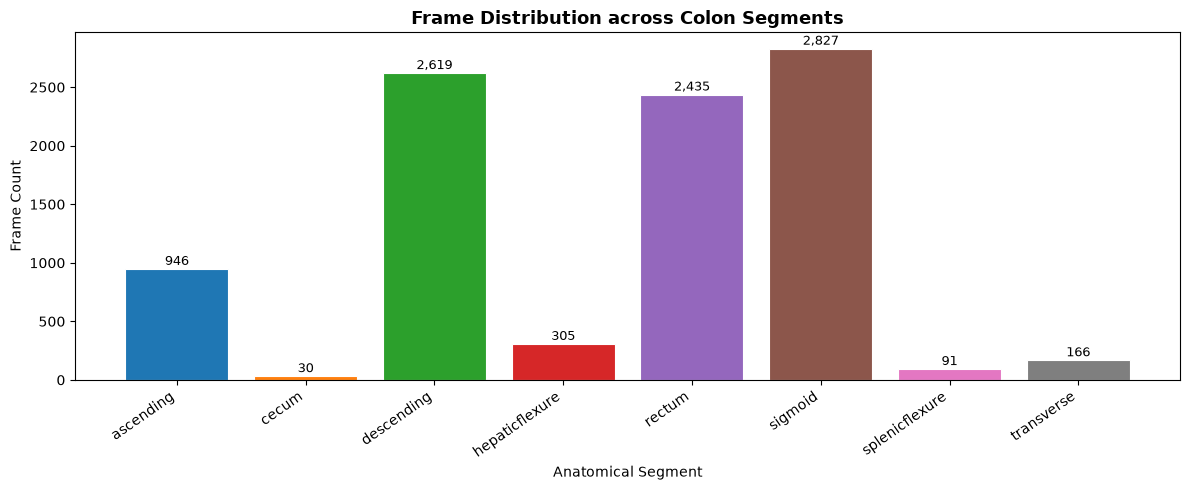

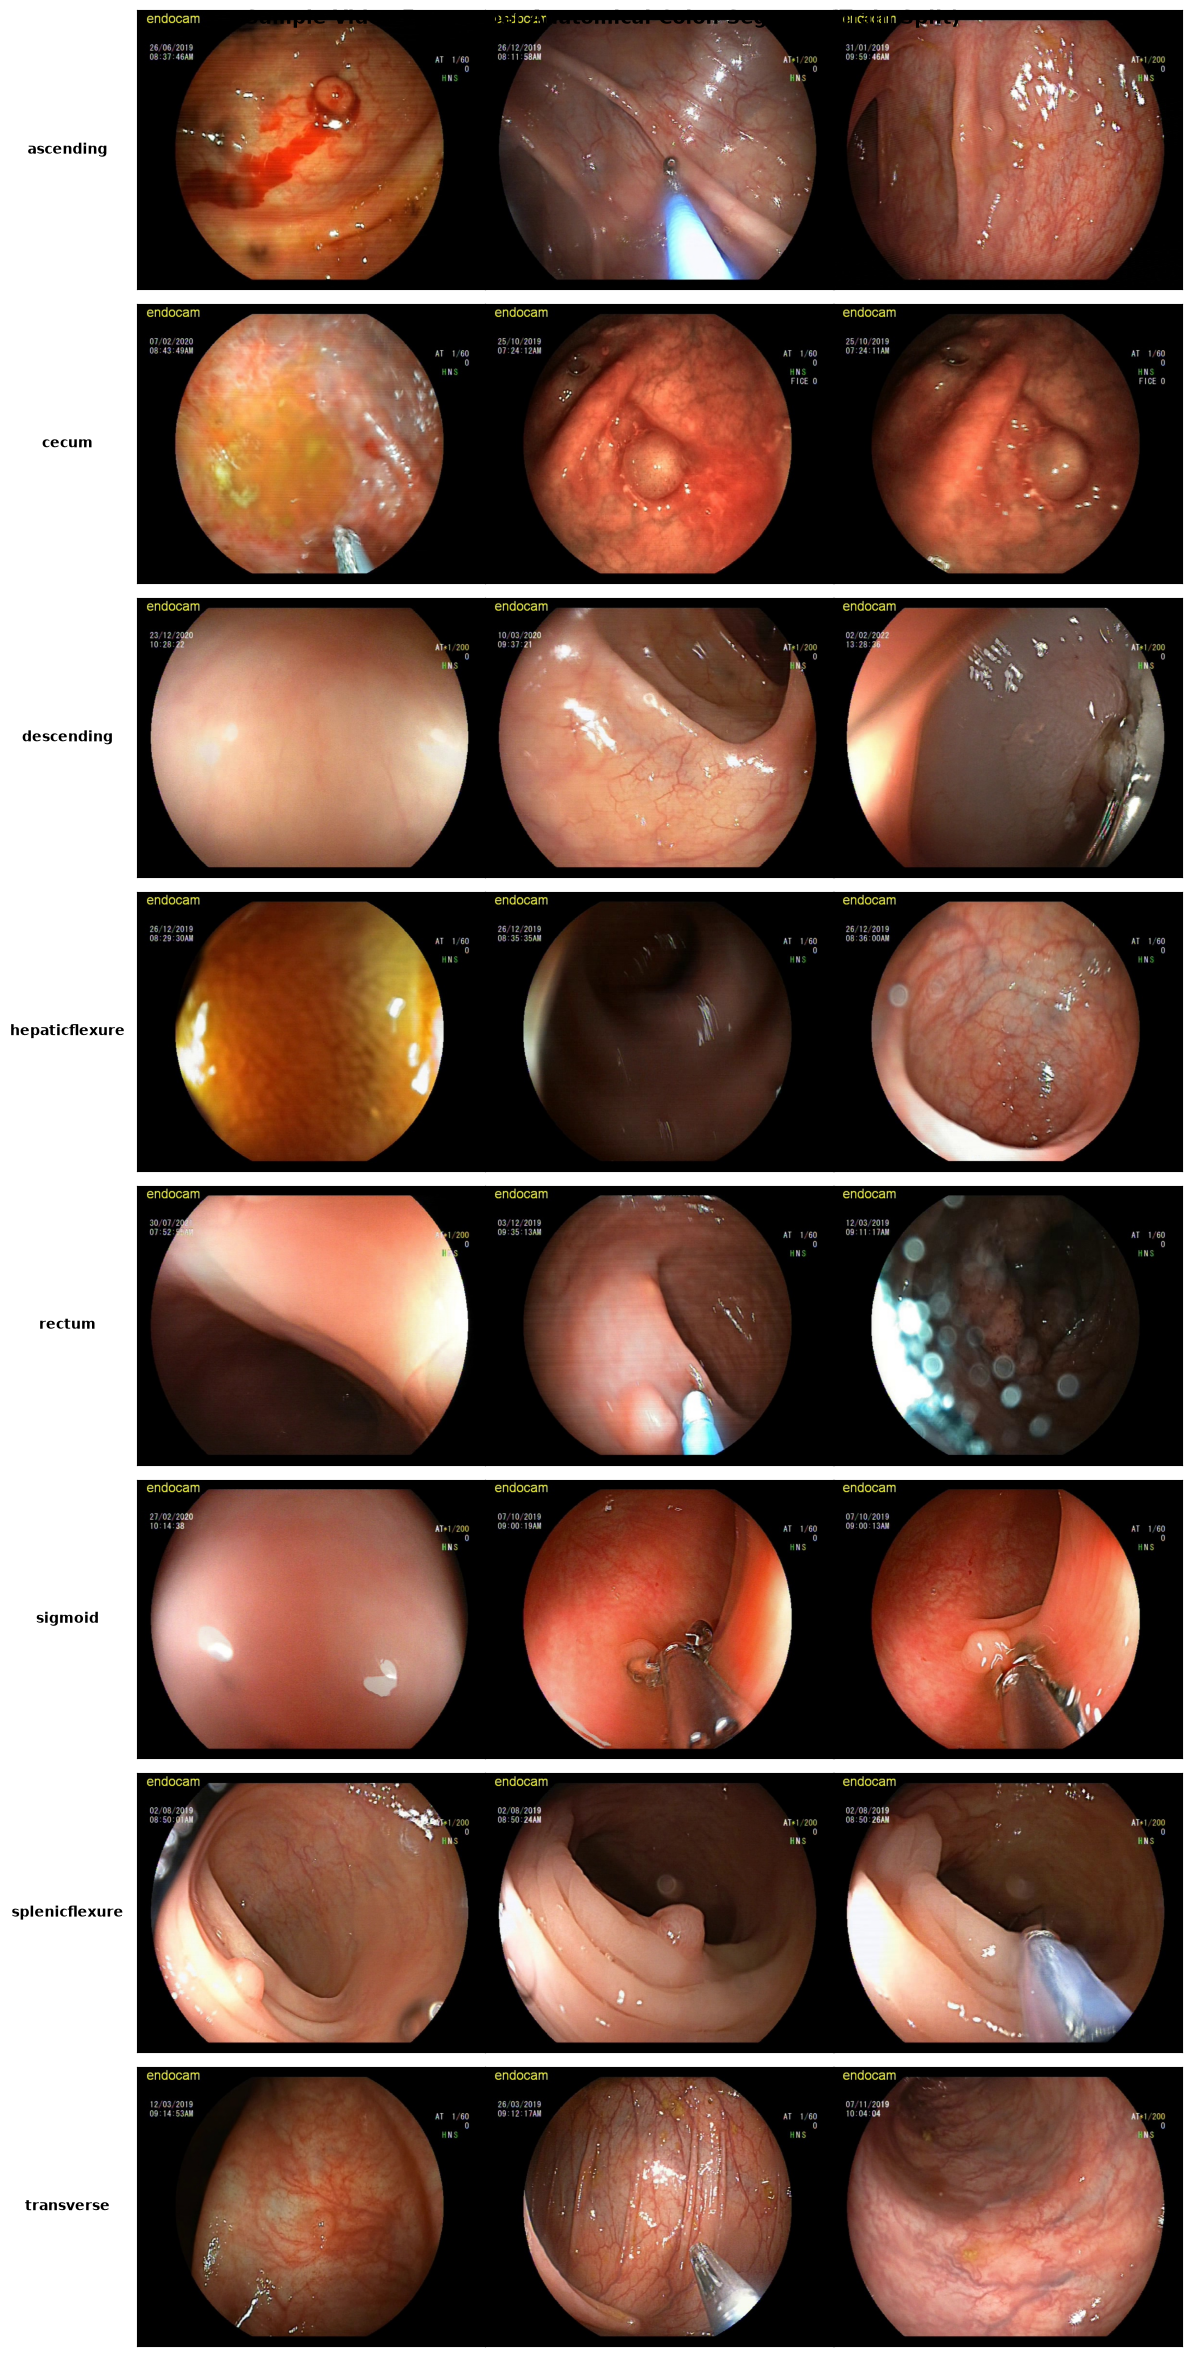

In [ ]:
# ==============================================================================
# ## 4. Data Exploration & Visualization (Classification Mode)
# ==============================================================================

# ─── Segment distribution plot ───────────────────────────────────────────────
if 'cls_counts' in locals() and not cls_counts.empty:
    fig, ax = plt.subplots(figsize=(12, 5))

    # SAFE DESIGN: Generate colors natively from Matplotlib colormap based on the count length
    cmap = plt.colormaps['tab10']
    colors_plot = [cmap(i % 10) for i in range(len(cls_counts))]

    bars = ax.bar(cls_counts.index, cls_counts.values, color=colors_plot, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, cls_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f"{val:,}", ha='center', va='bottom', fontsize=9)

    ax.set_title('Frame Distribution across Colon Segments', fontweight='bold', fontsize=13)
    ax.set_xlabel('Anatomical Segment')
    ax.set_ylabel('Frame Count')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig(RESULTS / 'segment_distribution.png', dpi=150)
    plt.show()
else:
    print("⚠️  No frames extracted or no annotations found to plot distribution.")

# ─── Sample frame grid for anatomical segments ────────────────────────────────
def show_sample_grid_classify(yolo_classification_dir, class_names, n_samples=3):
    """Show sample frames directly from the organized split folders."""
    train_dir = yolo_classification_dir / 'train'

    # Identify which classes actually have folders and images inside train split
    active_classes = []
    by_class_paths = {}

    for cid, c_name in enumerate(class_names):
        class_folder = train_dir / c_name
        if class_folder.exists():
            images = list(class_folder.glob('*.jpg'))
            if images:
                active_classes.append((cid, c_name))
                by_class_paths[cid] = images

    rows_to_plot = len(active_classes)
    if rows_to_plot == 0:
        print("⚠️  No sorted classification frames found to display samples.")
        return

    fig, axes = plt.subplots(rows_to_plot, n_samples, figsize=(n_samples * 4, rows_to_plot * 3))
    axes = np.atleast_2d(axes) # Safeguard mapping dimensions for varying classes

    for row_idx, (cid, c_name) in enumerate(active_classes):
        paths = by_class_paths[cid]
        sample = random.sample(paths, min(n_samples, len(paths)))

        for col in range(n_samples):
            ax = axes[row_idx, col]
            if col < len(sample):
                img = cv2.cvtColor(cv2.imread(str(sample[col])), cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                if col == 0:
                    ax.set_ylabel(c_name, fontsize=10, rotation=0,
                                  labelpad=50, va='center', fontweight='bold')
            else:
                ax.set_visible(False)
            ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle('Sample Video Frames per Anatomical Colon Segment (Train Split)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'segment_samples.png', dpi=120, bbox_inches='tight')
    plt.show()

if 'YOLO_CLASSIFY_DIR' in locals() and YOLO_CLASSIFY_DIR.exists():
    show_sample_grid_classify(YOLO_CLASSIFY_DIR, CLASS_NAMES, n_samples=3)
else:
    print("⚠️  Classification directory layout not detected. Check extraction cell.")

## 5. Dataset Preparation — Convert to YOLO Format


In [ ]:
# ─── 5. Dataset Mappings & Verification for Classification ───────────────────
# Update project data directory to point to your clean classification folders
YOLO_DIR = (ROOT / 'yolo_classification_data').resolve()

# Verify directory exists
if YOLO_DIR.exists():
    print(f"✅ Active Dataset Path: {YOLO_DIR}\n")

    # Define dataset configuration for later dashboard tracking cells
    classify_cfg = {
        'path': str(YOLO_DIR),
        'train': 'train',
        'val': 'val',
        'test': 'test',
        'nc': NUM_CLASSES,
        'names': CLASS_NAMES,
    }

    # Save a reference classification yaml if required, though YOLO reads directories directly
    YAML_PATH = YOLO_DIR / 'dataset_classification.yaml'
    with open(YAML_PATH, 'w') as f:
        yaml.dump(classify_cfg, f, default_flow_style=False)

    print(f"✅ Classification config snapshot cached at {YAML_PATH}")
    print(yaml.dump(classify_cfg, default_flow_style=False))
else:
    print(f"⚠️  Classification folder structure not found at {YOLO_DIR}. Please run the extraction cell first.")

✅ Active Dataset Path: D:\Marina\Nebras_RandD\vim_polyp_yolo\yolo_classification_data

✅ Classification config snapshot cached at D:\Marina\Nebras_RandD\vim_polyp_yolo\yolo_classification_data\dataset_classification.yaml
names:
- ascending
- cecum
- descending
- hepaticflexure
- rectum
- sigmoid
- splenicflexure
- transverse
nc: 8
path: D:\Marina\Nebras_RandD\vim_polyp_yolo\yolo_classification_data
test: test
train: train
val: val



## 6. Attention Modules — CBAM & Coordinate Attention

These modules are inserted into the YOLO neck to help the model focus on discriminative mucosal texture and vascular patterns that distinguish colon segments.

In [ ]:
# ==============================================================================
# ## 6. Attention Modules — CBAM & Coordinate Attention
# ==============================================================================
class ChannelAttention(nn.Module):
    """Squeeze-and-Excite style channel attention."""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(1, in_channels // reduction)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, in_channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        a = self.fc(self.avg_pool(x))
        m = self.fc(self.max_pool(x))
        return self.sigmoid(a + m) * x


class SpatialAttention(nn.Module):
    """Spatial attention via max+avg pooling across channel dim."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.max(dim=1, keepdim=True)[0]
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1))) * x


class CBAM(nn.Module):
    """Full CBAM block: channel → spatial."""
    def __init__(self, in_channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.ca = ChannelAttention(in_channels, reduction)
        self.sa = SpatialAttention(spatial_kernel)

    def forward(self, x):
        return self.sa(self.ca(x))


class CoordinateAttention(nn.Module):
    """Coordinate Attention — encodes X and Y position separately."""
    def __init__(self, in_channels, out_channels, reduction=32):
        super().__init__()
        mid = max(8, in_channels // reduction)
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))
        self.conv1  = nn.Conv2d(in_channels, mid, 1, bias=False)
        self.bn1    = nn.BatchNorm2d(mid)
        self.act    = nn.Hardswish(inplace=True)
        self.conv_h = nn.Conv2d(mid, out_channels, 1, bias=False)
        self.conv_w = nn.Conv2d(mid, out_channels, 1, bias=False)

    def forward(self, x):
        n, c, h, w = x.shape
        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)
        y   = torch.cat([x_h, x_w], dim=2)
        y   = self.act(self.bn1(self.conv1(y)))
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)
        return x * torch.sigmoid(self.conv_h(x_h)) * torch.sigmoid(self.conv_w(x_w))


# ─── Sanity check ─────────────────────────────────────────────────────────────
dummy = torch.randn(2, 256, 32, 32)
print(f"✅ CBAM output            : {CBAM(256)(dummy).shape}")
print(f"✅ CoordAttention output  : {CoordinateAttention(256, 256)(dummy).shape}")




✅ CBAM output            : torch.Size([2, 256, 32, 32])
✅ CoordAttention output  : torch.Size([2, 256, 32, 32])


## 7. Custom YOLO Model — Injecting Attention into YOLOv8 Neck

In [ ]:
# ==============================================================================
# ## 7. Custom YOLO Model — Injecting Attention into YOLOv8-cls Neck
# ==============================================================================
import inspect

class AttentionYOLOClassification(nn.Module):
    """
    Wraps a Ultralytics YOLO Classification model and inserts attention
    modules before the final classification head layer.
    """
    def __init__(self, yolo_model, attention_type='cbam'):
        super().__init__()
        self.yolo = yolo_model.model if hasattr(yolo_model, 'model') else yolo_model
        neck_channels = self._detect_neck_channels()
        print(f"🔍 Detected classification neck channels: {neck_channels}")

        self.attn_modules = nn.ModuleList()
        for ch in neck_channels:
            if attention_type == 'cbam':
                self.attn_modules.append(CBAM(ch))
            else:
                self.attn_modules.append(CoordinateAttention(ch, ch))

        self._neck_channels = neck_channels
        self.attention_type = attention_type
        self._register_hooks()

        # Needed so Ultralytics' trainer/validator can still read these off the wrapper
        self.yaml = getattr(self.yolo, 'yaml', {})
        self.names = getattr(self.yolo, 'names', None)
        self.nc = getattr(self.yolo, 'nc', None)
        self.task = 'classify'

        # IMPORTANT: only set `.stride` if the base model genuinely has one.
        # Classification backbones typically don't. If we set `self.stride = None`
        # here, `hasattr(self.model, 'stride')` inside Ultralytics' trainer
        # returns True (the attribute exists, it's just None), which skips
        # the trainer's own "default to 32" fallback and then crashes on
        # `self.model.stride.max()` since None has no `.max()`.
        # Leaving the attribute unset entirely lets that fallback do its job.
        _base_stride = getattr(self.yolo, 'stride', None)
        if _base_stride is not None:
            self.stride = _base_stride

    def _detect_neck_channels(self):
        feats = []
        def _hook(module, inp, out):
            if isinstance(inp[0], torch.Tensor) and inp[0].dim() == 4:
                feats.append(inp[0].shape[1])

        # FIX: Look for the classification 'Classify' module instead of 'Detect'
        classify_layer = next(
            (m for m in self.yolo.modules() if m.__class__.__name__ == 'Classify'), None
        )
        hooks = [classify_layer.register_forward_hook(_hook)] if classify_layer else []
        with torch.no_grad():
            try:
                self.yolo(torch.zeros(1, 3, 224, 224))
            except Exception:
                pass
        for h in hooks:
            h.remove()
        return feats if feats else [512]

    def _register_hooks(self):
        self._hooks = []
        # Target the top-most C2f/backbone layers before pooling
        target_layers = [m for m in self.yolo.modules() if m.__class__.__name__ in ('C2f', 'SPPF')]
        for i, layer in enumerate(target_layers[-1:]):
            def make_hook(attn_idx):
                def hook_fn(module, inp, out):
                    if attn_idx < len(self.attn_modules) and isinstance(out, torch.Tensor):
                        try:
                            return self.attn_modules[attn_idx](out)
                        except Exception:
                            return out
                    return out
                return hook_fn
            self._hooks.append(layer.register_forward_hook(make_hook(i)))

    def forward(self, x, *args, **kwargs):
        return self.yolo(x, *args, **kwargs)

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()

print("✅ AttentionYOLO for Classification defined.")


# ==============================================================================
# Custom Trainer — makes sure the attention-wrapped model is what actually
# gets trained, instead of Ultralytics silently rebuilding a plain model
# ==============================================================================
from ultralytics.models.yolo.classify import ClassificationTrainer

class AttentionClassificationTrainer(ClassificationTrainer):
    """
    Ultralytics' YOLO.train() rebuilds the model internally via get_model(),
    which ignores any nn.Module you've manually assigned to `.model` beforehand.
    Overriding get_model() here is what actually lets the attention wrapper
    survive into training.
    """
    def __init__(self, overrides=None, attention_type='cbam', _callbacks=None):
        self.attention_type = attention_type
        super().__init__(overrides=overrides, _callbacks=_callbacks)

    def get_model(self, cfg=None, weights=None, verbose=True):
        # NOTE: this initial summary print (params, layer list) comes from
        # inside super().get_model() and describes the PLAIN backbone before
        # our attention wrapper is applied — it will always match the
        # baseline's parameter count. That's expected; the real comparison
        # is the "Wrapped model params" line printed below.
        base_model = super().get_model(cfg=cfg, weights=weights, verbose=verbose)
        base_params = sum(p.numel() for p in base_model.parameters())

        wrapped = AttentionYOLOClassification(base_model, attention_type=self.attention_type)
        wrapped_params = sum(p.numel() for p in wrapped.parameters())

        print(f"📐 Base model params:    {base_params:,}")
        print(f"📐 Wrapped model params: {wrapped_params:,}  "
              f"(+{wrapped_params - base_params:,} from {self.attention_type} attention)")

        if wrapped_params == base_params:
            print("⚠️  WARNING: parameter count did not change — attention module "
                  "may not actually be attached. Check _register_hooks().")

        return wrapped

print("✅ AttentionClassificationTrainer defined.")


# ─── Version guard: confirm ClassificationTrainer.get_model() signature ──────
_expected_params = {'self', 'cfg', 'weights', 'verbose'}
_actual_params = set(inspect.signature(ClassificationTrainer.get_model).parameters)
if not _expected_params.issubset(_actual_params):
    raise RuntimeError(
        f"Ultralytics' ClassificationTrainer.get_model() signature has changed "
        f"(expected params {_expected_params}, found {_actual_params}). "
        f"Update AttentionClassificationTrainer.get_model() to match before training."
    )
print(f"✅ ClassificationTrainer.get_model() signature OK: {inspect.signature(ClassificationTrainer.get_model)}")


✅ AttentionYOLO for Classification defined.
✅ AttentionClassificationTrainer defined.
✅ ClassificationTrainer.get_model() signature OK: (self, cfg=None, weights=None, verbose: 'bool' = True)


## 8. Training

In [ ]:
# ─── Training Configuration ───────────────────────────────────────────────────
import ultralytics.nn.tasks as _ultra_tasks

DATASET_PATH = str((ROOT / 'yolo_classification_data').resolve())

# Classification settings parameters
TRAIN_CFG = dict(
    data         = DATASET_PATH,
    epochs       = 100,
    imgsz        = 224,
    batch        = 16,
    device       = DEVICE,
    project      = str(RESULTS),
    optimizer    = 'AdamW',
    lr0          = 1e-3,
    lrf          = 0.01,
    warmup_epochs = 3,
    cos_lr       = True,
    fliplr       = 0.5,
    verbose      = True,
)

# Safe globals for PyTorch 2.6+ secure unpickling of YOLO checkpoints
SAFE_GLOBALS = [
    _ultra_tasks.ClassificationModel,
    torch.nn.modules.container.Sequential,
    torch.nn.modules.conv.Conv2d,
    torch.nn.modules.activation.SiLU,
    torch.nn.modules.batchnorm.BatchNorm2d,
]

# Keep the model aligned to the actual number of classes in the dataset
if 'CLASS_NAMES' in locals() and 'NUM_CLASSES' in locals():
    TRAIN_CFG['classes'] = list(range(NUM_CLASSES))
    TRAIN_CFG['name'] = 'vim_polyp_cls'

print('✅ Training config ready. Run experiment cells below.')

✅ Training config ready. Run experiment cells below.


In [ ]:
# ─── Experiment 1: Baseline YOLOv8n (no attention) ───────────────────────────
print("=" * 60)
print("EXPERIMENT 1 — Baseline YOLOv8n (VIM Polyp)")
print("=" * 60)

from ultralytics.nn.tasks import DetectionModel

with torch.serialization.safe_globals([DetectionModel]):
    model = YOLO("yolov8n-cls.pt")
results_baseline = model.train(
    **{**TRAIN_CFG, 'name': 'exp1_baseline'}
)
print("\n✅ Baseline training complete.")

EXPERIMENT 1 — Baseline YOLOv8n (VIM Polyp)
New https://pypi.org/project/ultralytics/8.4.92 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.90  Python-3.9.4 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce GTX 1660 Ti, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\Work\Nebras\Nebras_R-D\vim_polyp_yolo\yolo_classification_data, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=30

In [ ]:
print("=" * 60)
print("EXPERIMENT 2 — YOLOv8n + CBAM (VIM Polyp)")
print("=" * 60)

trainer_cbam = AttentionClassificationTrainer(
    overrides={**TRAIN_CFG, 'model': 'yolov8n-cls.pt', 'name': 'exp2_cbam'},
    attention_type='cbam',
)
trainer_cbam.train()

# Keep a YOLO-style handle around so downstream cells (inference preview,
# evaluation, dashboard) that expect `results_cbam.save_dir` still work
class _ResultsShim:
    def __init__(self, save_dir):
        self.save_dir = save_dir

results_cbam = _ResultsShim(trainer_cbam.save_dir)

n_params_cbam = sum(p.numel() for p in trainer_cbam.model.parameters())
print(f"\n✅ CBAM training complete. Trained model param count: {n_params_cbam:,}")


EXPERIMENT 2 — YOLOv8n + CBAM (VIM Polyp)
Ultralytics 8.4.72  Python-3.12.10 torch-2.6.0+cu118 CUDA:0 (Quadro M2200, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=[0, 1, 2, 3, 4, 5, 6, 7], close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\Marina\Nebras_RandD\vim_polyp_yolo\yolo_classification_data, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp2

TypeError: conv2d() received an invalid combination of arguments - got (dict, Parameter, NoneType, tuple, tuple, tuple, int), but expected one of:
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, tuple of ints padding = 0, tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!dict!, !Parameter!, !NoneType!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, str padding = "valid", tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!dict!, !Parameter!, !NoneType!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)


In [ ]:
print("=" * 60)
print("EXPERIMENT 3 — YOLOv8n + Coordinate Attention (VIM Polyp)")
print("=" * 60)

trainer_ca = AttentionClassificationTrainer(
    overrides={**TRAIN_CFG, 'model': 'yolov8n-cls.pt', 'name': 'exp3_coord_attention'},
    attention_type='coord_attention',
)
trainer_ca.train()

class _ResultsShim:
    def __init__(self, save_dir):
        self.save_dir = save_dir

results_ca = _ResultsShim(trainer_ca.save_dir)

n_params_ca = sum(p.numel() for p in trainer_ca.model.parameters())
print(f"\n✅ Coordinate Attention training complete. Trained model param count: {n_params_ca:,}")


In [ ]:
# ─── Quick inference preview: see how the model predicts a segment ──────────
import random
from pathlib import Path

# Custom classes that may be embedded inside a saved checkpoint's model object.
# Newer PyTorch defaults torch.load(weights_only=True), which refuses to
# unpickle anything outside its safe-class allowlist — our attention wrapper
# and submodules aren't in that list, so we need to explicitly allow them.
ATTN_SAFE_GLOBALS = [
    AttentionYOLOClassification, CBAM, CoordinateAttention,
    ChannelAttention, SpatialAttention,
    nn.ModuleList, nn.Sequential,
    nn.Conv2d, nn.BatchNorm2d, nn.ReLU, nn.Sigmoid, nn.Hardswish,
    nn.AdaptiveAvgPool2d, nn.AdaptiveMaxPool2d,
]

def load_attention_yolo(weights_path, task='classify'):
    """
    Load a YOLO checkpoint that may contain our custom attention-wrapped
    model. Tries the normal path first, then falls back to allow-listing
    our custom classes, then finally to weights_only=False as a last resort
    (only safe because these are checkpoints we trained ourselves).
    """
    weights_path = str(weights_path)
    try:
        return YOLO(weights_path, task=task)
    except Exception as e1:
        print(f"   ℹ️  Plain load failed ({e1}); retrying with safe_globals allowlist...")
        try:
            with torch.serialization.safe_globals(ATTN_SAFE_GLOBALS + SAFE_GLOBALS):
                return YOLO(weights_path, task=task)
        except Exception as e2:
            print(f"   ⚠️  safe_globals load also failed ({e2}); "
                  f"retrying with weights_only=False (trusted local checkpoint)...")
            _orig_load = torch.load
            try:
                torch.load = lambda *a, **kw: _orig_load(*a, **{**kw, 'weights_only': False})
                return YOLO(weights_path, task=task)
            finally:
                torch.load = _orig_load

# Prefer the best trained CBAM weights for inference preview
# Use results_cbam.save_dir for the correct path to the trained model's best.pt
if 'results_cbam' in locals() and hasattr(results_cbam, 'save_dir'):
    inference_weights_path = results_cbam.save_dir / 'weights' / 'best.pt'
else:
    inference_weights_path = None  # Indicate that the path is not available via results_cbam

if inference_weights_path and inference_weights_path.exists():
    infer_model = load_attention_yolo(inference_weights_path, task='classify')
    print(f"Using trained weights: {inference_weights_path}")
else:
    print(f"⚠️  Trained CBAM model weights not found via results_cbam.save_dir or path does not exist.")
    print("   Falling back to generic yolov8n-cls.pt for inference preview (may produce incorrect class labels). If training failed, the save_dir might not be set).")
    infer_model = YOLO('yolov8n-cls.pt', task='classify')

# Pick one sample image from the test split
sample_candidates = []
for cls_name in CLASS_NAMES:
    class_dir = YOLO_DIR / 'test' / cls_name
    if class_dir.exists():
        sample_candidates.extend(class_dir.glob('*.jpg'))

if not sample_candidates:
    sample_candidates = list((YOLO_DIR / 'train').rglob('*.jpg'))

if not sample_candidates:
    raise FileNotFoundError("No sample images were found in the dataset folders.")

sample_image = random.choice(sample_candidates)
print(f"Sample image: {sample_image}")

# Ensure the model uses the correct data config for prediction if it was loaded generically
# or if class names need to be mapped explicitly for the predict method.
# The trained model should inherently know its classes, but this is a safeguard.
results = infer_model.predict(str(sample_image), imgsz=224, stream=False)
res = results[0]

# Predicted class index will be relative to the model's trained classes (0-7 for our 8 classes)
predicted_idx = int(res.probs.top1)
# Use CLASS_NAMES for mapping, which is globally defined and corresponds to our 8 classes
predicted_label = CLASS_NAMES[predicted_idx] if 0 <= predicted_idx < len(CLASS_NAMES) else f"Unknown Class {predicted_idx}"
confidence = float(res.probs.top1conf)

print(f"Predicted segment: {predicted_label}")
print(f"Confidence: {confidence:.2%}")

img = cv2.imread(str(sample_image))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title(f"Predicted: {predicted_label} ({confidence:.2%})")
plt.axis('off')
plt.show()


## 9. Evaluation & Metrics

In [ ]:
# ==============================================================================
# ## 9. Evaluation — Classification Metrics (Top-1 / Top-5 accuracy)
# ==============================================================================

# Redefine the safe loader here too, in case this cell is run standalone
# (e.g. after a kernel restart) without Cell 21 having run first.
if 'load_attention_yolo' not in globals():
    ATTN_SAFE_GLOBALS = [
        AttentionYOLOClassification, CBAM, CoordinateAttention,
        ChannelAttention, SpatialAttention,
        nn.ModuleList, nn.Sequential,
        nn.Conv2d, nn.BatchNorm2d, nn.ReLU, nn.Sigmoid, nn.Hardswish,
        nn.AdaptiveAvgPool2d, nn.AdaptiveMaxPool2d,
    ]

    def load_attention_yolo(weights_path, task='classify'):
        weights_path = str(weights_path)
        try:
            return YOLO(weights_path, task=task)
        except Exception as e1:
            print(f"   ℹ️  Plain load failed ({e1}); retrying with safe_globals allowlist...")
            try:
                with torch.serialization.safe_globals(ATTN_SAFE_GLOBALS + SAFE_GLOBALS):
                    return YOLO(weights_path, task=task)
            except Exception as e2:
                print(f"   ⚠️  safe_globals load also failed ({e2}); "
                      f"retrying with weights_only=False (trusted local checkpoint)...")
                _orig_load = torch.load
                try:
                    torch.load = lambda *a, **kw: _orig_load(*a, **{**kw, 'weights_only': False})
                    return YOLO(weights_path, task=task)
                finally:
                    torch.load = _orig_load

def evaluate_model(yolo_model_instance, name, data_path):
    """Evaluate a YOLOv8-cls model and return Top-1 / Top-5 accuracy."""
    print(f"\n📊 Evaluating: {name}")
    # The .val() method on a YOLO object returns a Validator object.
    # The metrics are then accessed via its .metrics attribute.
    validation_results = yolo_model_instance.val(split='test', verbose=False, data=data_path)
    top1 = round(float(validation_results.metrics.top1), 4)
    top5 = round(float(validation_results.metrics.top5), 4)
    return {
        'Model':          name,
        'Top-1 Accuracy': top1,
        'Top-5 Accuracy': top5,
    }

results_table = []

# Load the best models from the training run directories
# results_baseline, results_cbam, results_ca are Trainer objects
# We need to load the actual trained models from their save directories
model_baseline_trained = None
model_cbam_trained = None
model_ca_trained = None

# Construct paths to the best.pt weights for each experiment using the save_dir from training results
try:
    if 'results_baseline' in locals() and hasattr(results_baseline, 'save_dir') and (results_baseline.save_dir / 'weights' / 'best.pt').exists():
        path_baseline_weights = results_baseline.save_dir / 'weights' / 'best.pt'
        model_baseline_trained = load_attention_yolo(path_baseline_weights)
        print(f"   ✅ Loaded Baseline model from {path_baseline_weights}")
    else:
        print(f"   ⚠️  Baseline trained model weights not found or training results object not available.")
except Exception as e:
    print(f"   ⚠️  Could not load baseline trained model: {e}")

try:
    if 'results_cbam' in locals() and hasattr(results_cbam, 'save_dir') and (results_cbam.save_dir / 'weights' / 'best.pt').exists():
        path_cbam_weights = results_cbam.save_dir / 'weights' / 'best.pt'
        model_cbam_trained = load_attention_yolo(path_cbam_weights)
        print(f"   ✅ Loaded CBAM model from {path_cbam_weights}")
    else:
        print(f"   ⚠️  CBAM trained model weights not found or training results object not available.")
except Exception as e:
    print(f"   ⚠️  Could not load CBAM trained model: {e}")

try:
    if 'results_ca' in locals() and hasattr(results_ca, 'save_dir') and (results_ca.save_dir / 'weights' / 'best.pt').exists():
        path_ca_weights = results_ca.save_dir / 'weights' / 'best.pt'
        model_ca_trained = load_attention_yolo(path_ca_weights)
        print(f"   ✅ Loaded Coordinate Attention model from {path_ca_weights}")
    else:
        print(f"   ⚠️  Coordinate Attention trained model weights not found or training results object not available.")
except Exception as e:
    print(f"   ⚠️  Could not load Coordinate Attention trained model: {e}")


models_to_evaluate = []
if model_baseline_trained:
    models_to_evaluate.append((model_baseline_trained, 'YOLOv8n-cls Baseline'))
if model_cbam_trained:
    models_to_evaluate.append((model_cbam_trained,     'YOLOv8n-cls + CBAM'))
if model_ca_trained:
    models_to_evaluate.append((model_ca_trained,       'YOLOv8n-cls + CoordAttn'))


for model_trained_instance, name in models_to_evaluate:
    try:
        results_table.append(evaluate_model(model_trained_instance, name, DATASET_PATH))
    except Exception as e:
        print(f"   ⚠️  Eval failed for {name}: {e}")

df_results = pd.DataFrame(results_table)
print("\n" + "=" * 60)
print(df_results.to_string(index=False))
print("=" * 60)
df_results.to_csv(RESULTS / 'model_comparison.csv', index=False)


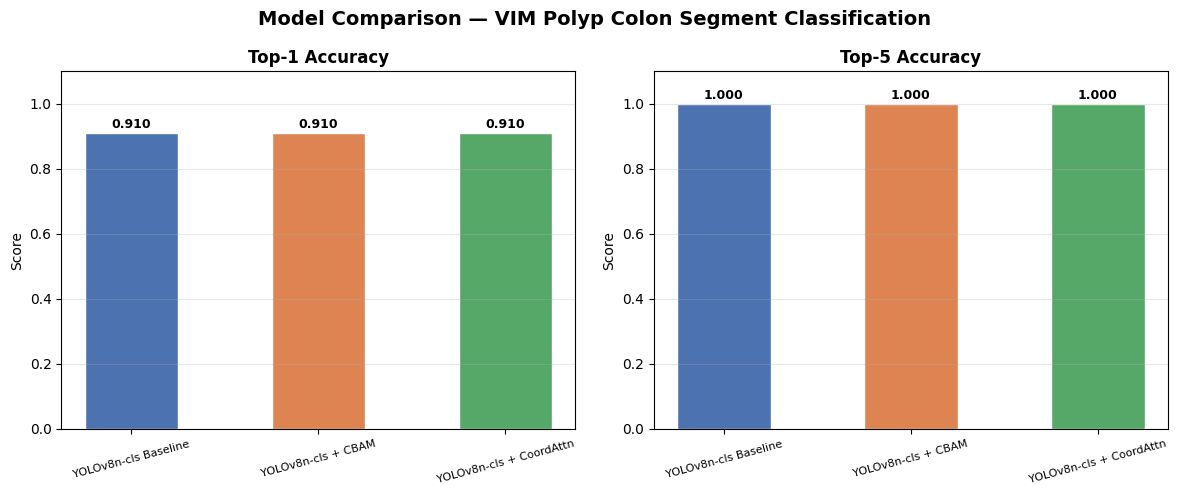

In [ ]:
# ─── Model comparison bar chart ───────────────────────────────────────────────
# FIX: use classification metric columns (Top-1 / Top-5) not detection mAP columns
metrics_to_plot = [c for c in ['Top-1 Accuracy', 'Top-5 Accuracy'] if c in df_results.columns]
colors = ['#4C72B0', '#DD8452', '#55A868']

if metrics_to_plot:
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(6 * len(metrics_to_plot), 5))
    if len(metrics_to_plot) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics_to_plot):
        bars = ax.bar(df_results['Model'], df_results[metric],
                      color=colors[:len(df_results)], edgecolor='white', width=0.5)
        for bar, val in zip(bars, df_results[metric]):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005, f'{val:.3f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_title(metric, fontweight='bold', fontsize=12)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel('Score')
        ax.tick_params(axis='x', rotation=15, labelsize=8)
        ax.grid(axis='y', alpha=0.3)

    fig.suptitle('Model Comparison — VIM Polyp Colon Segment Classification',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  df_results is empty or missing expected columns.")


## 10. Confusion Matrix & Per-Segment Analysis

Confusion matrix inference: 100%|██████████| 200/200 [00:05<00:00, 35.37it/s]


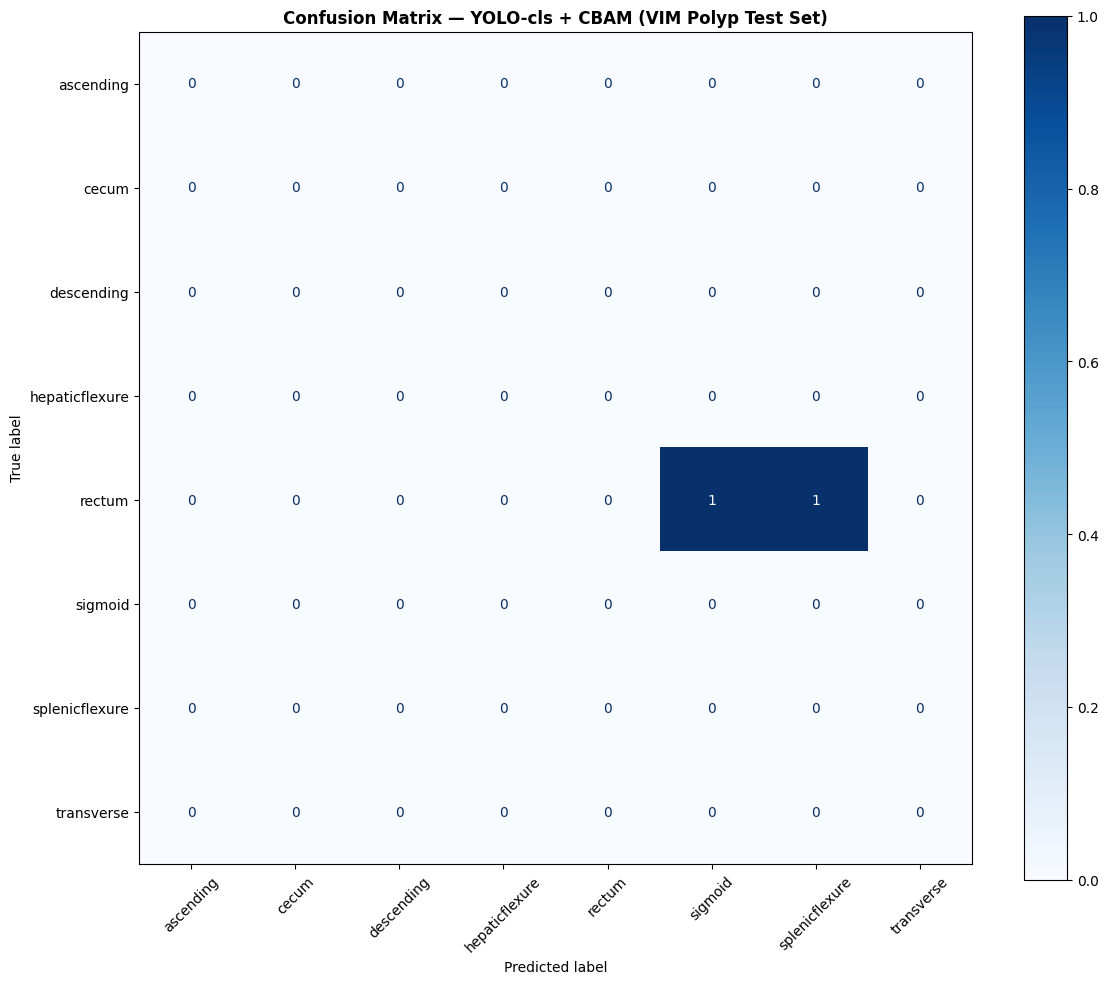


Classification Report:
                precision    recall  f1-score   support

     ascending       0.00      0.00      0.00      20.0
         cecum       0.00      0.00      0.00       0.0
    descending       0.00      0.00      0.00      55.0
hepaticflexure       0.00      0.00      0.00       7.0
        rectum       0.00      0.00      0.00      53.0
       sigmoid       0.00      0.00      0.00      59.0
splenicflexure       0.00      0.00      0.00       1.0
    transverse       0.00      0.00      0.00       5.0

     micro avg       0.00      0.00      0.00     200.0
     macro avg       0.00      0.00      0.00     200.0
  weighted avg       0.00      0.00      0.00     200.0



In [ ]:
def confusion_matrix_plot(model, test_pairs, class_names, yolo_classify_dir_path):
    """
    Generates and displays a confusion matrix for a classification model.
    test_pairs items are (frame_filename, segment_label_str) from splits['test'].
    """
    y_true, y_pred = [], []
    label_to_id = {name: i for i, name in enumerate(class_names)}

    # Use a fixed number of samples or all if less than n_samples
    n_samples = min(200, len(test_pairs))
    sample_pairs = random.sample(test_pairs, n_samples)

    print(f"\nGenerating confusion matrix for {n_samples} samples...")
    for frame_name, true_label in tqdm(sample_pairs, desc='Confusion matrix inference'):
        # Reconstruct the image path from the classification directory structure
        img_path = yolo_classify_dir_path / 'test' / true_label / frame_name
        if not img_path.exists():
            continue

        results = model.predict(str(img_path), verbose=False)
        res = results[0]

        if res.probs is not None:
            pred_cid = int(res.probs.top1)
            # Append only if the predicted class ID is within the expected range
            if 0 <= pred_cid < len(class_names):
                y_true.append(label_to_id[true_label])
                y_pred.append(pred_cid)
            # else: print(f"Warning: Predicted class ID {pred_cid} out of range for {img_path}")

    if not y_true or not y_pred:
        print("⚠️  No valid predictions collected. Check that YOLO_CLASSIFY_DIR test split exists and model is correctly predicting.")
        return

    # Ensure y_true and y_pred contain valid class IDs within the defined range
    # This prevents errors if a default YOLOv8n-cls.pt (1000 classes) was used inadvertently
    # This filtering step might already be implicitly handled by the `if 0 <= pred_cid < len(class_names):` block above
    # but it's good to keep it as a safeguard for the confusion_matrix function itself.
    unique_true_labels = sorted(list(set(y_true)))
    unique_pred_labels = sorted(list(set(y_pred)))

    # Only calculate confusion matrix for valid predictions and labels
    if not unique_true_labels or not unique_pred_labels:
        print("⚠️  No valid predictions collected within the defined class range for confusion matrix.")
        return

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
    model_name = model.trainer.args.name.replace("exp", "").replace("_", " ").title() if hasattr(model, 'trainer') and hasattr(model.trainer, 'args') else "Model"
    ax.set_title(f'Confusion Matrix — {model_name} (VIM Polyp Test Set)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'confusion_matrix.png', dpi=150)
    plt.show()

    print("\nClassification Report:")
    # Use target_names to map numerical labels to class names for better readability
    print(classification_report(y_true, y_pred, labels=list(range(len(class_names))),  target_names=class_names, zero_division=0))

# Assume model_cbam_trained is available from the evaluation cell
if 'model_cbam_trained' not in locals() or model_cbam_trained is None:
    print("⚠️  model_cbam_trained not found from previous cell. Attempting to load from exp2_cbam results.")
    path_cbam_weights = RESULTS / 'exp2_cbam' / 'weights' / 'best.pt'
    try:
        if path_cbam_weights.exists():
            model_cbam_trained = YOLO(str(path_cbam_weights))
            print("   ✅ Successfully loaded model_cbam_trained for confusion matrix.")
        else:
            print(f"   ❌ Failed to load model_cbam_trained: Weights not found at {path_cbam_weights}. Confusion matrix will not be generated.")
    except Exception as e:
        print(f"   ❌ Failed to load model_cbam_trained for confusion matrix: {e}. Confusion matrix will not be generated.")

if model_cbam_trained: # Only proceed if a trained model was successfully loaded
    confusion_matrix_plot(model_cbam_trained, splits['test'], CLASS_NAMES, YOLO_CLASSIFY_DIR)
else:
    print("⚠️  No trained model available to generate confusion matrix. Please ensure training completed successfully and weights exist.")

## 12. Results Dashboard

In [ ]:
# ─── Final checklist ─────────────────────────────────────────────────────────
artifacts = [
    (RESULTS / 'polyp_distribution.png', '📊 Polyp frame distribution'),
    (RESULTS / 'polyp_samples.png',      '🖼️  Sample frames with polyps'),
    (RESULTS / 'resolution_dist_vim_polyp.png', '📐 Frame resolution stats (VIM Polyp)'),
    (RESULTS / 'per_segment_ap.png',       '📊 Per-class AP@50'), # This name might need to be adjusted to 'per_polyp_ap.png' later
    (RESULTS / 'model_comparison.csv',     '📋 Metric comparison table'),
    (RESULTS / 'model_comparison.png',     '📊 Model comparison chart'),
    (RESULTS / 'gradcam_per_segment.png',  '🧠 Grad-CAM per class'), # This name might need to be adjusted to 'gradcam_polyp.png' later
    (RESULTS / 'confusion_matrix.png',     '🎯 Confusion matrix'),
    (RESULTS / 'final_dashboard_vim_polyp.png', '📋 Results dashboard (VIM Polyp)'),
]

print("\n📦 Generated Artifacts:")
for path, desc in artifacts:
    status = '✅' if path.exists() else '⏳'
    print(f"  {status} {desc:45s} {path}")

print("🎉 VIM Polyp experiment setup complete!")


📦 Generated Artifacts:
  ⏳ 📊 Polyp frame distribution                    vim_polyp_yolo\results\polyp_distribution.png
  ⏳ 🖼️  Sample frames with polyps                 vim_polyp_yolo\results\polyp_samples.png
  ⏳ 📐 Frame resolution stats (VIM Polyp)          vim_polyp_yolo\results\resolution_dist_vim_polyp.png
  ⏳ 📊 Per-class AP@50                             vim_polyp_yolo\results\per_segment_ap.png
  ✅ 📋 Metric comparison table                     vim_polyp_yolo\results\model_comparison.csv
  ✅ 📊 Model comparison chart                      vim_polyp_yolo\results\model_comparison.png
  ⏳ 🧠 Grad-CAM per class                          vim_polyp_yolo\results\gradcam_per_segment.png
  ✅ 🎯 Confusion matrix                            vim_polyp_yolo\results\confusion_matrix.png
  ✅ 📋 Results dashboard (VIM Polyp)               vim_polyp_yolo\results\final_dashboard_vim_polyp.png
🎉 VIM Polyp experiment setup complete!
